In [1]:
import numpy as nm
import pandas as ps
import matplotlib.pyplot as plt
import seaborn as sb

# **User Funnel Analysis to Identify Drop-offs and Improve Conversion**

**Data Import from csv**

In [2]:
df = ps.read_csv("/content/drive/MyDrive/Colab Notebooks/funnel-data.csv")

**Data Review**

In [3]:
df.head()

,user_id,stage,conversion
0,user_0,homepage,True
1,user_1,homepage,True
2,user_2,homepage,True
3,user_3,homepage,True
4,user_4,homepage,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17175 entries, 0 to 17174
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     17175 non-null  object
 1   stage       17175 non-null  object
 2   conversion  17175 non-null  bool  
dtypes: bool(1), object(2)
memory usage: 285.3+ KB


In [5]:
df.describe()

,user_id,stage,conversion
count,17175,17175,17175
unique,17175,5,2
top,user_17174,homepage,True
freq,1,10000,13014


In [6]:
funnel = df['stage'].unique()
funnel

array(['homepage', 'product_page', 'cart', 'checkout', 'purchase'],
      dtype=object)

# **Funnel ( homepage -> product_page -> cart -> checkout -> purchase )**

# **Problem :** Where Users Drop Off

In [7]:
piedata = df['stage'].value_counts()
piedata

,count
stage,
homepage,10000
product_page,5000
cart,1500
checkout,450
purchase,225


#**Overall data Analysis**

([<matplotlib.patches.Wedge at 0x7e6fd66a3560>,
 [Text(-0.28105533238260405, 1.063488551954982, 'homepage'),
  Text(-0.15292436045214747, -1.089318199600237, 'product_page'),
  Text(0.9538831449057293, -0.5478201765769087, 'cart'),
  Text(1.0851279558939464, -0.1802701287996039, 'checkout'),
  Text(1.0990685272036964, -0.04525894950502133, 'purchase')],
 [Text(-0.15330290857232945, 0.5800846647027174, '58.2%'),
  Text(-0.08341328751935315, -0.5941735634183111, '29.1%'),
  Text(0.5202998972213069, -0.2988110054055865, '8.7%'),
  Text(0.5918879759421525, -0.09832916116342032, '2.6%'),
  Text(0.5994919239292889, -0.02468669973001163, '1.3%')])

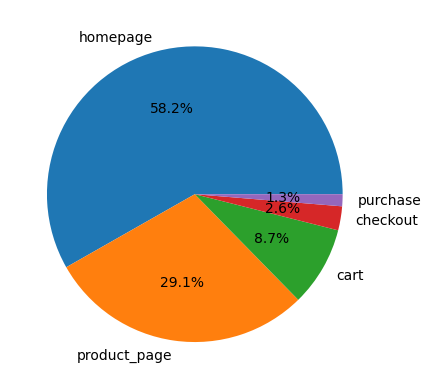

In [8]:
plt.pie(piedata,labels=funnel,autopct='%1.1f%%')

**Insight :** Most of the user leave the site after visit homepage .

In [9]:
tdata = df[df['conversion'] == True ]
fdata = df[df['conversion'] == False ]

In [10]:
tcnvdata= tdata['stage'].value_counts()
fcnvdata= fdata['stage'].value_counts()
print("Conversion Happend , ")
print(tcnvdata)
print()
print("Conversion Didn't Happend , ")
print(fcnvdata)

Conversion Happend , 
stage
homepage        10000
product_page     2515
cart              449
checkout           36
purchase           14
Name: count, dtype: int64

Conversion Didn't Happend , 
stage
product_page    2485
cart            1051
checkout         414
purchase         211
Name: count, dtype: int64


**Analysis accroding to conversion**

Text(0.5, 1.0, "Conversion did't Happend")

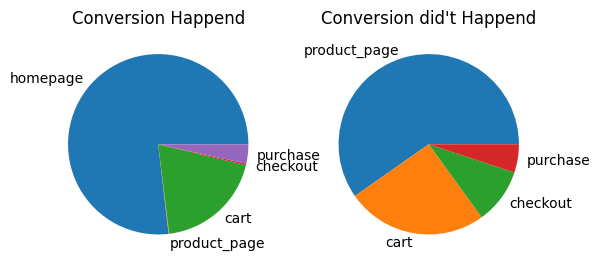

In [11]:
lbs=['homepage','purchase','product_page','checkout','cart']
plt.subplot(1,2,1)
ttcnvdata=tcnvdata[['homepage','purchase','product_page','checkout','cart']]
plt.pie(ttcnvdata,labels=funnel)
plt.title("Conversion Happend")

lbl=[ 'product_page', 'cart', 'checkout', 'purchase']
plt.subplot(1,2,2)
plt.pie(fcnvdata,labels=lbl)
plt.title("Conversion did't Happend")

 **Insight:**
Most users drop at early stages (especially product page → cart), so improving that step can significantly increase overall conversions.

In [12]:
count=df['stage'].value_counts()
count

,count
stage,
homepage,10000
product_page,5000
cart,1500
checkout,450
purchase,225


In [27]:
drop1 = count['homepage'] - count['product_page']
drop2 = count['product_page'] - count['cart']
drop3 = count['cart'] - count['checkout']
drop4 = count['checkout'] - count['purchase']

total=count['homepage']+count['product_page']+count['cart']+count['checkout']+count['purchase']

finaldrop= count['homepage']-count['purchase']

print("The Funnel :\nhomepage -> product_page -> cart -> checkout -> purchase")
print("Drop down flow ,\n",drop1,"->",drop2,"->",drop3,"->",drop4)

print()
def prc(count,a,b) :
    p=((count[b] / count[a])*100)
    return p

print(f"homepage -> product_page drop {prc(count, 'homepage', 'product_page'):.0f}%")
print(f"product_page -> cart drop {prc(count, 'product_page', 'cart'):.0f}%")
print(f"cart -> checkout drop {prc(count, 'cart', 'checkout'):.0f}%")
print(f"checkout -> purchase drop {prc(count, 'checkout', 'purchase'):.0f}%")

print()

print("Only", (count['purchase']/count['homepage'])*100, "% of people complete their purchase")

The Funnel :
homepage -> product_page -> cart -> checkout -> purchase
Drop down flow ,
 5000 -> 3500 -> 1050 -> 225

homepage -> product_page drop 50%
product_page -> cart drop 30%
cart -> checkout drop 30%
checkout -> purchase drop 50%

Only 2.25 % of people complete their purchase


**Insight :** Most user leave from the homepage . Improve homepage experience for the users .

# Key Findings:
- Biggest drop (50%) occurs between homepage → Cart, meaning users lose interest after initial engagement. .
- Very low amount of people complete their purchase .
- People usually leavw thw site from beginning of the funnel .

# Recommendations:
- Ensure better homepage experience.
- Target new users with offers .  
- Reduce steps before cart .